In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import globals.path as pth
import globals.imaging as im
import globals.design as dn
import matplotlib.ticker as mticker
import PcmPy as pcm
import pandas as pd
import seaborn as sb
from vis.vis import plot_im_sess
from util.util import get_trained_and_untrained

figDir = pth.figDir

plt.style.use('default')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


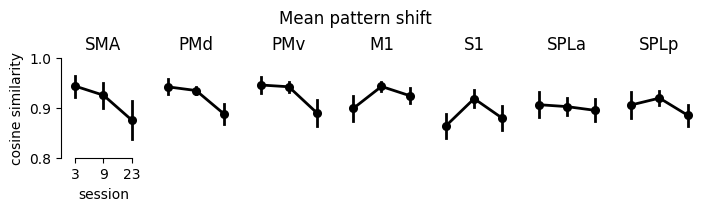

In [2]:
glm = 1
H = 'L'
atlas = 'ROI'
rois = im.rois[atlas][:-1]
df = pd.read_csv(os.path.join(pth.baseDir, pth.pcmDir, f'dist.trained-untrained.glm{glm}.{H}.tsv'), sep='\t',)
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)
plot_im_sess(fig, axs, df, rois, x='session', y='cos', dodge=None, color='k')
axs[0].set_ylim((.8, 1))
axs[0].spines['bottom'].set_bounds(0, 2)
axs[0].spines['left'].set_bounds(.8, 1)
axs[0].set_ylabel('cosine similarity')
axs[0].set_xlabel('session')
fig.suptitle('Mean pattern shift')
fig.savefig(os.path.join(figDir, f'mean_shift.{atlas}.glm{glm}.pdf'))
plt.show()

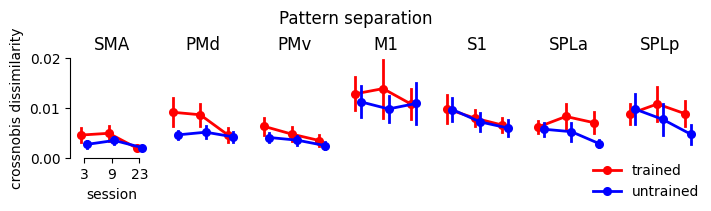

In [5]:
df = pd.read_csv(os.path.join(pth.baseDir, pth.pcmDir, f'dist.chord-session.glm{glm}.{H}.tsv'), sep='\t',)
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)
plot_im_sess(fig, axs, df, rois, x='session', y='dist', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'])
axs[0].spines['bottom'].set_bounds(0, 2)
axs[0].set_ylim([0, .02])
axs[0].spines['left'].set_bounds(0, .02)
axs[0].set_ylabel('crossnobis dissimilarity')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')
fig.suptitle('Pattern separation')
fig.savefig(os.path.join(figDir, f'pattern_separation.{atlas}.glm{glm}.pdf'))
plt.show()

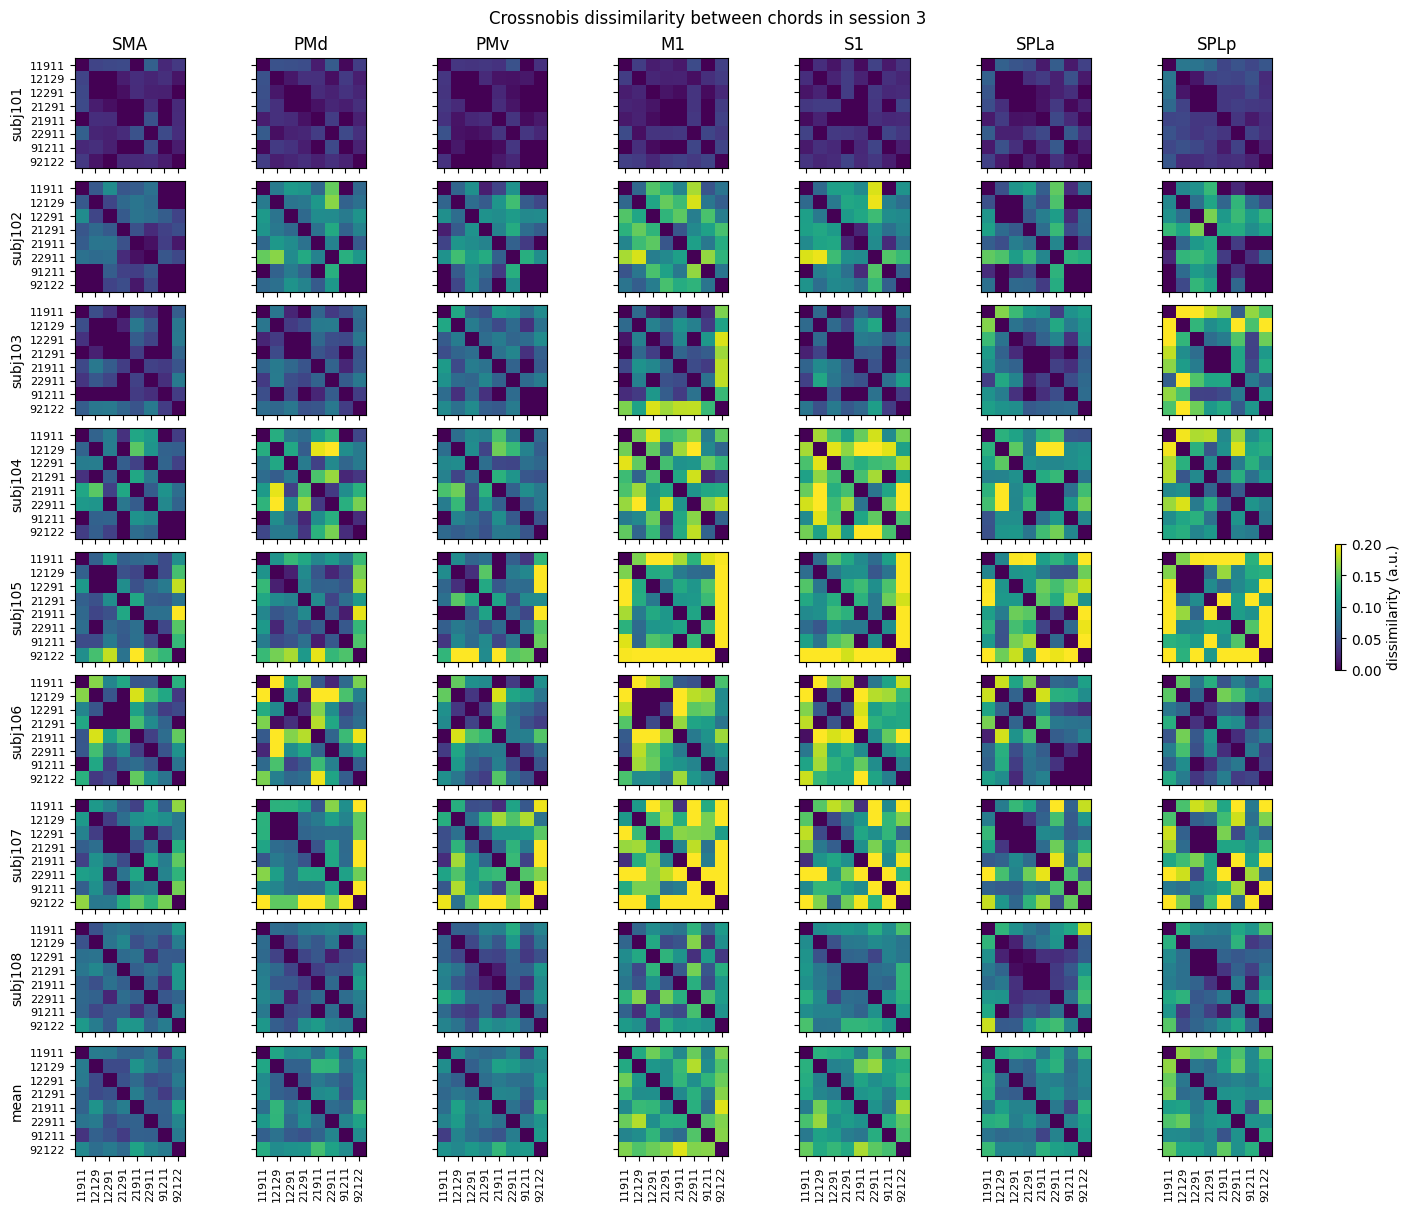

In [4]:
N = 8
participant_id = [101, 102, 103, 104, 105, 106, 107, 108]
chordID = [str(ch) for ch in dn.chordID]

fig, axs = plt.subplots(N + 1, len(rois), sharex=True, sharey=True, figsize=(14, 12), constrained_layout=True)

sess = 3
vmin, vmax = 0, .2
for r, roi in enumerate(rois):
    G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.chord-session.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G[:, 0]) # / np.trace(G))
    Dd = np.zeros_like(D)
    for i in range(N):
        trained_untrained = get_trained_and_untrained(participant_id[i])
        order = [trained_untrained.index(ch) for ch in chordID]
        Dd_tmp = D[i].copy()
        Dd_tmp = Dd_tmp[np.ix_(order, order)]
        Dd[i] = Dd_tmp
        ax = axs[i, r]
        Dd_tmp = np.sign(Dd_tmp) * np.sqrt(np.abs(Dd_tmp))
        ax.imshow(Dd_tmp, vmin=vmin, vmax=vmax)
        ax.set_yticks(np.arange(8))
        ax.set_yticklabels(dn.chordID, fontsize=8)
        ax.set_ylabel(f'subj{i + 101}') if r==0 else None
    Dd_m = Dd.mean(axis=0)
    Dd_m = np.sign(Dd_m) * np.sqrt(np.abs(Dd_m))
    axs[-1, r].imshow(Dd_m, vmin=vmin, vmax=vmax)
    axs[-1, r].set_xticks(np.arange(8))
    axs[-1, r].set_xticklabels(dn.chordID, rotation=90, fontsize=8)
    axs[-1, r].set_yticks(np.arange(8))
    axs[-1, r].set_yticklabels(dn.chordID, fontsize=8)
    axs[-1, r].set_ylabel(f'mean') if r==0 else None
    axs[0, r].set_title(roi)

cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.005)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle(f'Crossnobis dissimilarity between chords in session {sess}')
#fig.subplots_adjust(right=.85)

plt.show()